Cycle 2

E-Mart wants to gain a better understanding of how It provides value to its customers. Based on customer understanding, the retailer will focus on increasing sales by creating messaging that resonates with target audience. In other words, **The ultimate goal of this project is being able to target our users differently given their current status**. 

Therefore, we need to identify customer personas and their value.

- **Who are our best customers?**

- **Where are they?**

- **Who has the potential to become valuable customers?**

- **Which of our customers are most likely to respond to engagement campaigns?**

- **Which of our customers can be retained?**


# Customer Segmentation - RFV

![img](../images/rfm.png)

[RFM](https://www.barilliance.com/rfm-analysis/#tve-jump-17b4fc9cc54)<br>
[Cohort Analysis](https://www.barilliance.com/cohort-analysis/)

RFV segmentation allows marketers to target specific clusters of customers with communications that are much more relevant for their particular behavior – and thus generate much higher rates of response, plus increased loyalty and customer lifetime value.

## Agenda

[0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1 Recency Frequency Value](#1-Recency-Frequency-Value)<br>
&emsp;[1.1 RFV Analitycal Base Table](#1.1-RFV-Analitycal-Base-Table)<br>
&emsp;[1.2 Ranking](#1.2-Ranking)<br>
&emsp;[1.3 RFV Segmentation](#1.3-RFV-Segmentation)<br>

[2 Customer Analitycal Base Table](#2-Customer-Analitycal-Base-Table)

[3 Analysis](#3-Analysis)<br>
&emsp;[3.1 Sales and Profit](#3.1-Sales-and-Profit)<br>
&emsp;[3.2 Orders and Quantity of Products](#3.2-Orders-and-Quantity-of-Products)<br>
&emsp;[3.3 Recency and Frequency](#3.3-Recency-and-Frequency)<br>
&emsp;[3.4 Discount and Shipping Cost](#3.4-Discount-and-Shipping-Cost)<br>
&emsp;[3.5 Location](#3.5-Location)<br>

[4 Objective Answers](#4-Objective-Answers)<br>

[5 Strategies](#5-Strategies)<br>

## 0 Imports

In [1]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.graph import fig

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
directory = Directory("pr_v01_rfv", is_sub_project=True)
pd.set_option('display.max_columns', None)

%matplotlib inline

### 0.1 Helper Functions

In [2]:
def classify_customer(recency, frequency):
    if recency <= .2 and frequency <= .2:
        customer_category = "Hibernating"
    elif recency > .9 and frequency > .9:
        customer_category = "Champion"
    elif recency <= .55 and frequency <= .20:
        customer_category = "About to Sleep"
    elif recency <= .8 and frequency <= .20:
        customer_category = "Promising"
    elif recency > .8 and frequency < .20:
        customer_category = "New Customer"
    elif recency <= .2 and frequency > .2 and frequency <= .9:
        customer_category = "At Risk"
    elif recency > .2 and recency <= .55 and frequency >.2 and frequency <= .6:
        customer_category = "Need Attention"
    elif recency > .55 and frequency > .2 and frequency <= .6:
        customer_category = "Potential Loyalist"
    elif recency <= .2 and frequency > .9:
        customer_category = "About to Lose"
    elif recency > .2 and frequency > .6:
        customer_category = "Loyal"
    else:
        customer_category = "CATEGORY ERROR"
    return customer_category


def get_rfv_palette(categories, colors=None):
    """
    Defines colors of category for RFV customer segmentation plots.

    Parameters
    ----------
    categories: category name or list of categories to set a color.
    
    colors: list of colors to be used to color the categories.
    
    Returns
    -------
    segment_color: dict of categories and respective colors.
    """
    
    if colors is None:
        colors = ['#034488', '#027dc5', '#c5253d']
    segment_color = {
        'Champion': 'grey',
        'Loyal': 'grey',
        'Need Attention': 'grey',
        'Promising': 'grey',
        'Potential Loyalist': 'grey',
        'New Customer': 'grey',
        'Hibernating':'grey',
        'About to Sleep': 'grey',
        'About to Lose': 'grey', 
        'At Risk': 'grey',
    }
    if isinstance(categories, list):
        for i in range(len(categories)):
            segment_color[categories[i]] = colors[i]
    else:
        segment_color[categories] = colors[0]
    return segment_color


def frequency_plot(segments):
    fig()
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='frequency', y='value', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend([]);
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='frequency_rank', y='value_rank', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend(loc=(1.05, .5));
    plt.show()
    
def recency_plot(segments):
    fig()
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='recency', y='value', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend([]);
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='recency_rank', y='value_rank', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend(loc=(1.05, .5));
    plt.show()
    
    
def cluster_count_plot(data, cluster_col="cluster", palette='crest_r'):
    plt.box(False)
    ax = sns.countplot(y=cluster_col, data=data, palette=palette)
    plt.title('Quantity of Customers')
    plt.tick_params(axis='both', length=0)
    plt.xlabel(None)
    for p in ax.patches:
        ax.annotate('{:.0f}'.format(p.get_width()), (p.get_width()+5, p.get_y()+.5))

def compare_clusters(cluster, y, data, showfliers=False, xticks_rotation=0, figsize=(15, 5)):
    fig(figsize[0], figsize[1])
    plt.subplot( 1, 2, 1 )
    sns.boxplot( x=cluster, y=y[0], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    plt.subplot( 1, 2, 2 )
    sns.boxplot( x=cluster, y=y[1], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    

def cluster_stats(df, column, cluster='cluster', quantile_1=.8, quantile_2=.9):    
    stats = df.groupby(cluster)[[column]].describe()[column]
    quantiles = pd.concat([df.groupby(cluster)[[column]].quantile(quantile_1), df.groupby(cluster)[[column]].quantile(quantile_2)], axis=1)
    quantile_1_name, quantile_2_name = f'{round(quantile_1*100)}%', f'{round(quantile_2*100)}%'
    quantiles.columns = [quantile_1_name, quantile_2_name]
    stats = pd.concat([stats, quantiles], axis=1)
    return stats[['mean', 'std', 'min', '25%', '50%', '75%', quantile_1_name, quantile_2_name, 'max']]

### 0.2 Loading Data

In [3]:
raw_data = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "e_mart_data.parquet"]))
raw_data.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,postal_code,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,cost,profit_per_product,sales_without_discount,product_value,product_cost,order_date_year,order_date_month,order_date_day,is_profitable_sale
0,42433,AG-2011-2040-TB-11280,2011-01-01,2011-06-01,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,Algeria,NaN,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,266.70,53.070,408.30,186.42,133.350,2011,1,1,1
1,22253,IN-2011-47883-JH-15985,2011-01-01,2011-08-01,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,Australia,NaN,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,74.61,12.012,1116.18,368.82,356.808,2011,1,1,1


## 1 Recency Frequency Value

In [4]:
years = [2014]

data = raw_data.copy()
CURRENT_DATE = pd.to_datetime(f"01/01/{years[-1]+1}")

In [5]:
df = data.groupby("customer_id")[['order_date']].max()

### 1.1 RFV Analitycal Base Table

Recency - Days since last purchase.

Frequency - Total number orders.

Value - Sum of revenue.

_Average Value - Average of revenue._

In [6]:
aggregation = {
    'order_date': lambda date: (CURRENT_DATE - date.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'sales': 'sum', # Value    
}
df = data[data['order_date_year'].isin(years)].groupby("customer_id").agg(aggregation)
df.columns = ['recency','frequency','value']
df.head()

,recency,frequency,value
customer_id,,,
AA-10315,9,7,3889.2065
AA-10375,7,7,1904.5380
AA-10480,118,6,7752.9070
AA-10645,27,10,3539.8788
AA-315,3,3,787.3920


In [7]:
aux = data[data['order_date_year'].isin(years)].groupby("customer_id")[['sales']].mean()
aux.columns = ['avg_value']
df = pd.concat([df, aux], axis=1)

### 1.2 Ranking

<font color='grey'><strong>2nd Option: Clustering Algorithm</strong></font>

In [8]:
df[['recency_rank', 'frequency_rank', 'value_rank', 'avg_value_rank']] = df.rank(pct=True)
df['recency_rank'] = (1 - df['recency_rank']) # so that higher percentage means lower recency 
df.head()

,recency,frequency,value,avg_value,recency_rank,frequency_rank,value_rank,avg_value_rank
customer_id,,,,,,,,
AA-10315,9,7,3889.2065,228.776853,0.816347,0.621443,0.705493,0.614163
AA-10375,7,7,1904.5380,136.038429,0.860688,0.621443,0.497684,0.337525
AA-10480,118,6,7752.9070,775.290700,0.171741,0.550629,0.931833,0.985440
AA-10645,27,10,3539.8788,186.309411,0.588352,0.827267,0.674388,0.486433
AA-315,3,3,787.3920,262.464000,0.933488,0.320979,0.318994,0.702184


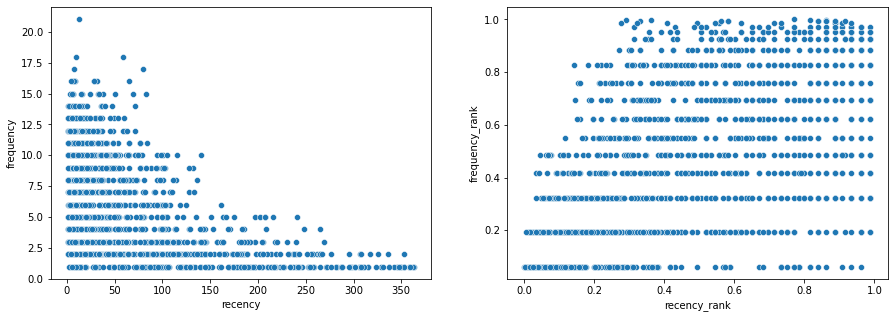

In [9]:
fig()
plt.subplot(1, 2, 1)
sns.scatterplot(x='recency', y='frequency', data=df);
plt.subplot(1, 2, 2)
sns.scatterplot(x='recency_rank', y='frequency_rank', data=df);

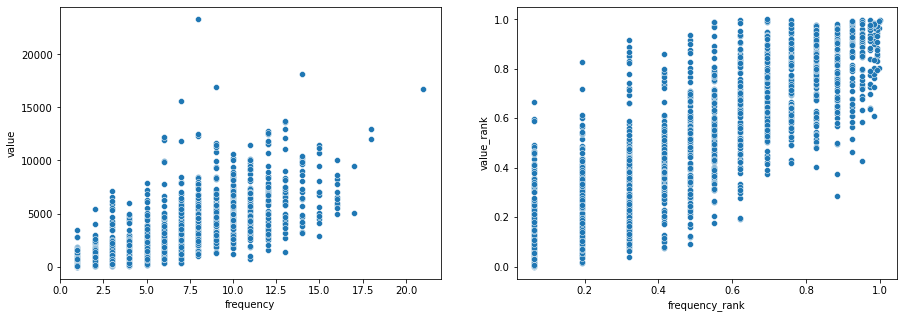

In [10]:
fig()
plt.subplot(1, 2, 1)
sns.scatterplot(x='frequency', y='value', data=df);
plt.subplot(1, 2, 2)
sns.scatterplot(x='frequency_rank', y='value_rank', data=df);

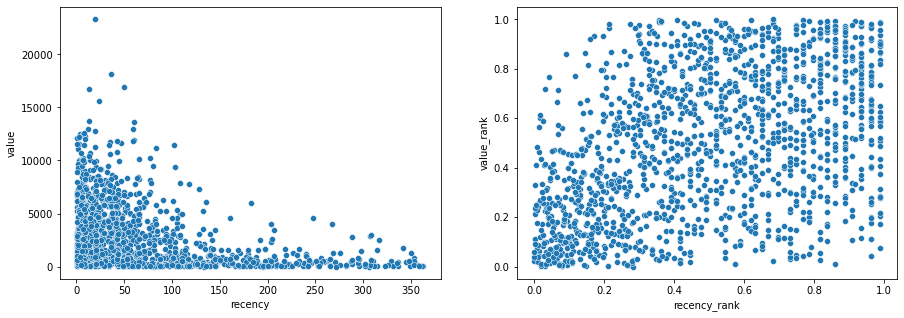

In [11]:
fig()
plt.subplot(1, 2, 1)
sns.scatterplot(x='recency', y='value', data=df);
plt.subplot(1, 2, 2)
sns.scatterplot(x='recency_rank', y='value_rank', data=df);

### 1.3 RFV Segmentation

- **Hibernating - Low Recency Low Frequency**<br>
Made purchase a long time ago and made few transactions.


- **About to sleep - Medium Recency Low Frequency**<br>
Client's about to stop purchasing.


- **Promising - Good Recency Low Frequency**<br>
There is some potential. Client that made a purchase recently and has the brand on his mind, client has potential to buy more.


- **New customer - High Recency Low Frequency**<br>
First purchase.


- **At Risk - Low Recency Medium Frequency**<br>
Client that made lots of purchases, but a long time ago. Client has used the products and for some reason stopped buying.



- **Need Attention - Medium Recency Medium Frequency**<br>
Good customer, but as time passes by client does not make a new purchases.




- **Potential loyalists - High Recency Medium Frequency**<br>
Client buy some quantity of products and keep buying.




- **About to lose - Low Recency High Frequency**<br>
Client has made many purchases, but he's not buying anymore.



- **Loyal - Medium Recency High Frequency**<br>
Our usual customers.



- **Champions - High Recency High Frequency**<br>
They buy a lot and are "always buying".

In [12]:
segment = {  
    'Hibernating': 'Low Recency Low Frequency. Made purchase a long time ago and made few transactions.',
    
    'About to Sleep': "Medium Recency Low Frequency. Client's about to stop purchasing.",
    
    'Promising': 'Good Recency Low Frequency. There is some potential. Client that made a purchase recently and has the brand on his mind, client has potential to buy more.',
    
    'New Customer':'High Recency Low Frequency. First purchase.',
    
    'At Risk': 'Low Recency Medium Frequency. Client that made lots of purchases, but a long time ago. Client has used the products and for some reason stopped buying.',
    
    'Need Attention': 'Medium Recency Medium Frequency. Good customer, but as time passes by client does not make a new purchases.',
    
    'Potential Loyalist': 'High Recency Medium Frequency. Client buy some quantity of products and keep buying.',
    
    'About to Lose': "Low Recency High Frequency. Client has made many purchases, but he's not buying anymore.",
    
    'Loyal': 'Medium Recency High Frequency. Our usual customers.',
    
    'Champion': 'High Recency High Frequency. They buy a lot and are "always buying".',
}    

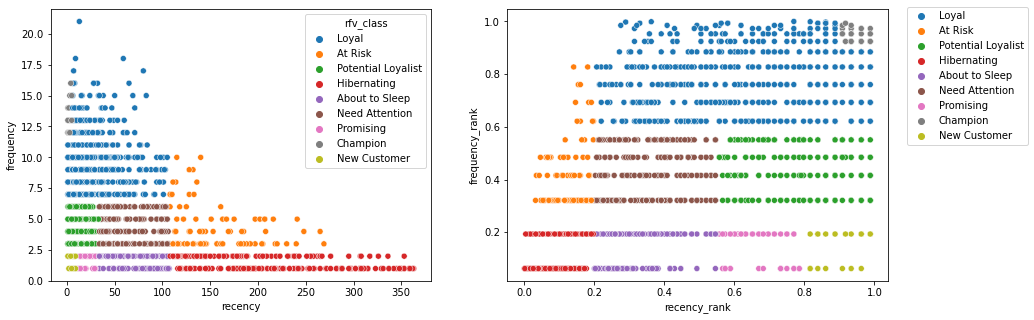

In [13]:
df['rfv_class'] = df.apply(lambda df: classify_customer(df['recency_rank'], df['frequency_rank']), axis=1)

fig()
plt.subplot(1, 2, 1)
sns.scatterplot(x='recency', y='frequency', hue='rfv_class', data=df);
plt.subplot(1, 2, 2)
sns.scatterplot(x='recency_rank', y='frequency_rank', hue='rfv_class', data=df);
plt.legend(loc=(1.05, .5));

In [14]:
df.groupby('rfv_class')['value'].describe().sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
rfv_class,,,,,,,,
Champion,40.0,6521.570217,2718.676732,2712.59904,4243.860925,6255.64090,7385.30970,12512.8473
Loyal,577.0,5064.024688,2840.775503,337.56700,3084.208000,4481.64040,6491.49844,23295.2184
Need Attention,206.0,1928.319484,1801.702105,95.01000,744.807000,1338.85418,2544.57450,11885.0992
Potential Loyalist,199.0,1896.414530,1750.966301,80.40000,691.995000,1328.44500,2490.68905,12252.1050
At Risk,93.0,1660.390930,1806.110405,43.06800,377.970000,970.14600,2214.50300,7841.2935
New Customer,22.0,863.445682,1226.998140,13.44000,161.706000,493.54500,946.55250,5460.0900
Hibernating,208.0,480.678538,622.225561,2.58000,71.488500,273.33000,590.33550,4042.5000
About to Sleep,116.0,416.419267,545.761192,2.05200,74.062500,226.93500,506.57550,3470.1000
Promising,50.0,414.851580,397.458004,14.20800,113.866500,274.06950,561.63300,1564.5600


In [15]:
segment['Champion'], segment['Loyal'], segment['About to Lose']

('High Recency High Frequency. They buy a lot and are "always buying".',
 'Medium Recency High Frequency. Our usual customers.',
 "Low Recency High Frequency. Client has made many purchases, but he's not buying anymore.")

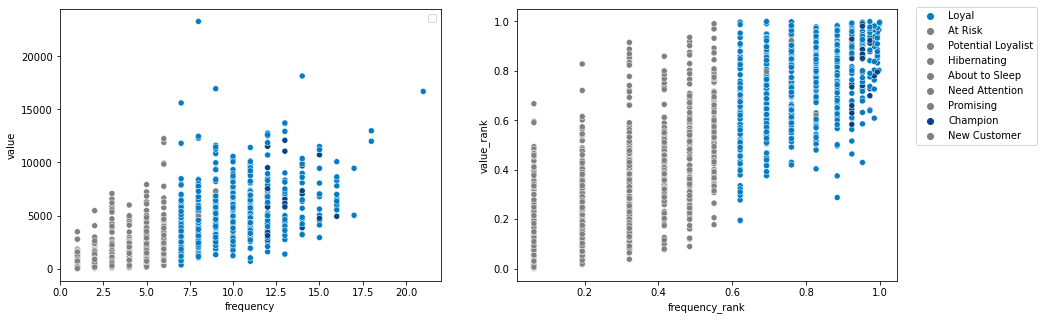

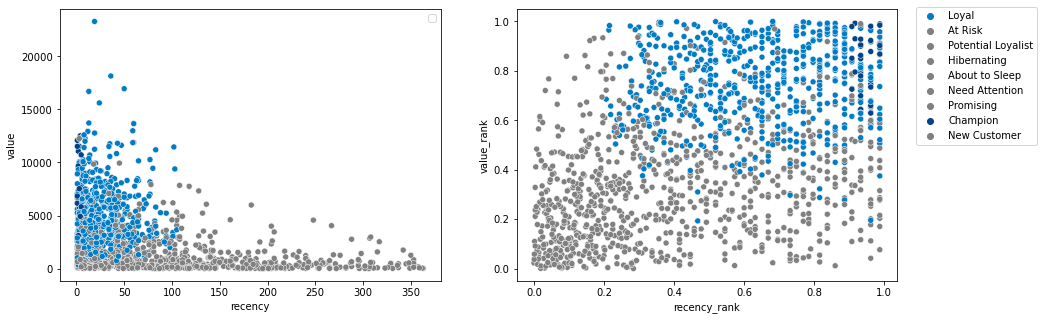

In [16]:
segments = ['Champion','Loyal', 'About to Lose']
frequency_plot(segments)
recency_plot(segments)

In [17]:
segment['New Customer'], segment['About to Sleep'], segment['Hibernating']

('High Recency Low Frequency. First purchase.',
 "Medium Recency Low Frequency. Client's about to stop purchasing.",
 'Low Recency Low Frequency. Made purchase a long time ago and made few transactions.')

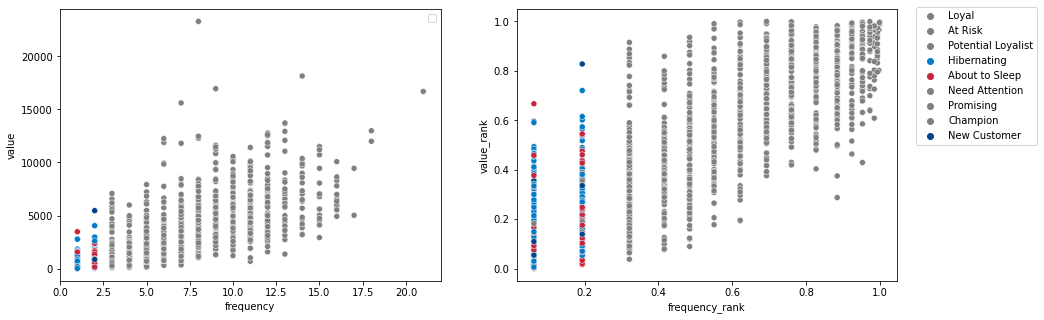

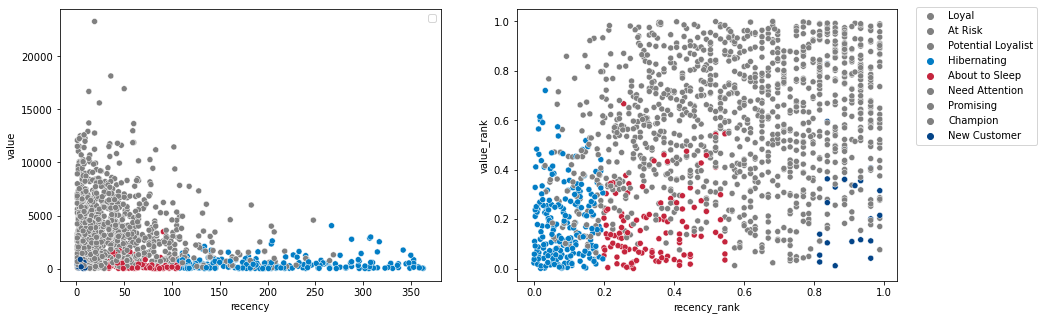

In [18]:
segments = ['New Customer', 'Hibernating', 'About to Sleep']
frequency_plot(segments)
recency_plot(segments)

In [19]:
segment['Promising'],  segment['Need Attention']

('Good Recency Low Frequency. There is some potential. Client that made a purchase recently and has the brand on his mind, client has potential to buy more.',
 'Medium Recency Medium Frequency. Good customer, but as time passes by client does not make a new purchases.')

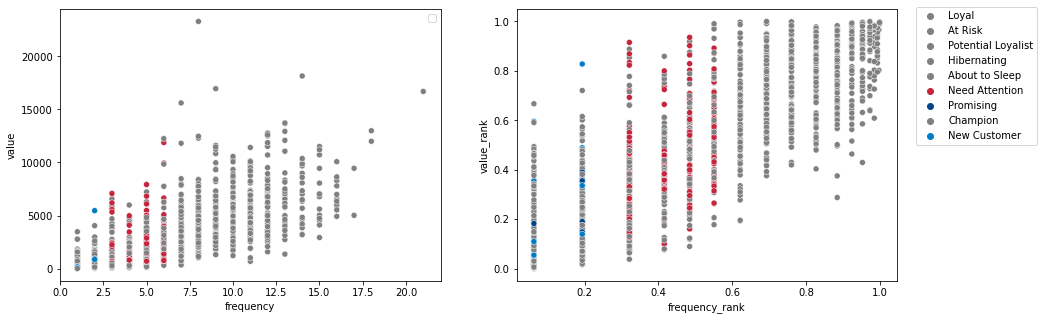

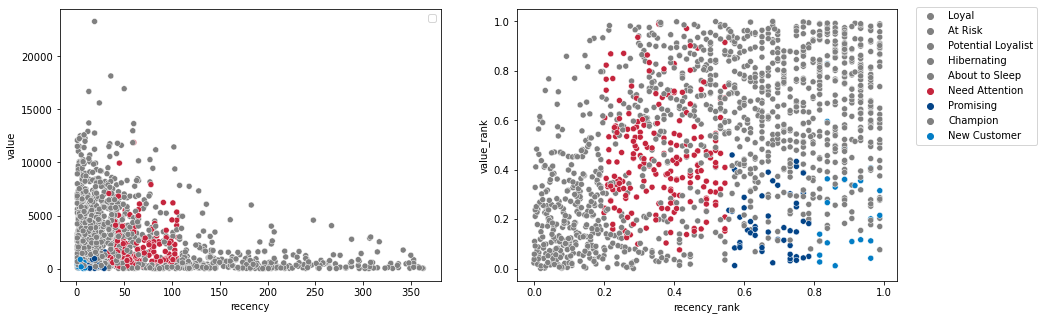

In [20]:
segments = ['Promising', 'New Customer', 'Need Attention']
frequency_plot(segments)
recency_plot(segments)

In [21]:
if len(years) > 1:
    file_name = f'customer_rfv_{years[0]}_to_{years[-1]}.parquet'
else:
    file_name = f'customer_rfv_{years[-1]}.parquet'
df[['rfv_class']].reset_index().to_parquet(join_paths([directory.DATA_DIR, 'processed', 'customer_segmentation', file_name]))

## 2 Customer Analitycal Base Table

In [22]:
aux = data[data['order_date_year'].isin(years)]

In [23]:
agg = {
    'sales':'sum',
    'quantity':'sum',
    'profit':'sum',
    'discount':'mean', # do not sum* - if we sum the discounts we'll see discounts greater than 1.0 (100%)
    'is_profitable_sale': 'mean',
    'shipping_cost':'sum', # we'll consider then that the same database modeling happened to shipping_cost? No
}
customer_abt_orders = aux.groupby(['customer_id', 'order_id']).agg(agg).reset_index()
customer_abt_orders.columns = ['customer_id', 'orders', 'total_sales', 'quantity',
                               'total_profit', 'avg_discount', 'is_profitable_sale', 'total_shipping_cost' ]
# customer_abt['avg_discount'].hist(); # if we sum the discounts we'll see discounts greater than 1.0 (100%)
# customer_abt['total_shipping_cost'].hist(); # No

customer_abt_orders

second_agg = {
    'orders':'nunique',
    'total_sales':'sum',
    'quantity':'sum',
    'total_profit':'sum',
    'avg_discount':'mean',
    'is_profitable_sale': 'mean',
    'total_shipping_cost':'sum',
}
customer_abt = customer_abt_orders.groupby('customer_id').agg(second_agg).reset_index()
customer_abt.head(3)

,customer_id,orders,total_sales,quantity,total_profit,avg_discount,is_profitable_sale,total_shipping_cost
0,AA-10315,7,3889.2065,53,534.2215,0.142857,0.642857,485.51
1,AA-10375,7,1904.5380,52,674.5155,0.080952,0.857143,212.86
2,AA-10480,6,7752.9070,45,415.2982,0.203333,0.500000,930.09


In [24]:
agg = {
    'product_id':'nunique',
    'sales':'sum',
    'quantity':'sum',
    'profit':'sum',
    'discount':'mean', # do not sum* - if we sum the discounts we'll see discounts greater than 1.0 (100%)
    'is_profitable_sale': 'mean',
    'shipping_cost':'sum', # we'll consider then that the same database modeling happened to shipping_cost? No
}
customer_abt_orders = aux.groupby(['customer_id', 'order_id']).agg(agg).reset_index()
customer_abt_orders.columns = ['customer_id', 'order_id', 'distinct_products', 'avg_ticket', 'quantity',
                               'avg_profit', 'avg_discount', 'is_profitable_sale', 'avg_shipping_cost' ]

customer_abt_orders.drop(columns=['order_id', 'quantity', 'is_profitable_sale', 'avg_discount'], inplace=True)
customer_abt_orders

second_agg = {
    'avg_ticket':'mean',
    'distinct_products':'sum',
    'avg_profit':'mean',
    'avg_shipping_cost':'mean',
}
customer_abt_averages = customer_abt_orders.groupby('customer_id').agg(second_agg).reset_index()
customer_abt_averages.head(3)

,customer_id,avg_ticket,distinct_products,avg_profit,avg_shipping_cost
0,AA-10315,555.600929,17,76.317357,69.358571
1,AA-10375,272.076857,14,96.359357,30.408571
2,AA-10480,1292.151167,10,69.216367,155.015000


In [25]:
customer_abt = customer_abt.merge(customer_abt_averages, on='customer_id', how='outer')#.isna().sum()
customer_abt.head(3)

,customer_id,orders,total_sales,quantity,total_profit,avg_discount,is_profitable_sale,total_shipping_cost,avg_ticket,distinct_products,avg_profit,avg_shipping_cost
0,AA-10315,7,3889.2065,53,534.2215,0.142857,0.642857,485.51,555.600929,17,76.317357,69.358571
1,AA-10375,7,1904.5380,52,674.5155,0.080952,0.857143,212.86,272.076857,14,96.359357,30.408571
2,AA-10480,6,7752.9070,45,415.2982,0.203333,0.500000,930.09,1292.151167,10,69.216367,155.015000


In [26]:
customer_abt = customer_abt.merge(df.reset_index(), on='customer_id', how='outer')
customer_abt['rfv_class'] = df['rfv_class'].values
customer_abt.head(2)

,customer_id,orders,total_sales,quantity,total_profit,avg_discount,is_profitable_sale,total_shipping_cost,avg_ticket,distinct_products,avg_profit,avg_shipping_cost,recency,frequency,value,avg_value,recency_rank,frequency_rank,value_rank,avg_value_rank,rfv_class
0,AA-10315,7,3889.2065,53,534.2215,0.142857,0.642857,485.51,555.600929,17,76.317357,69.358571,9,7,3889.2065,228.776853,0.816347,0.621443,0.705493,0.614163,Loyal
1,AA-10375,7,1904.5380,52,674.5155,0.080952,0.857143,212.86,272.076857,14,96.359357,30.408571,7,7,1904.5380,136.038429,0.860688,0.621443,0.497684,0.337525,Loyal


## 3 Analysis


- **Champions - High Recency High Frequency**<br>

        High Value.They buy a lot and are "always buying".
            Avg of orders: 12
            Avg of products: 94
            Avg Recency: 3 days
        About 1 purchase per month buying a lot of products.
        
        
- **Loyal - Medium Recency High Frequency**<br>
        
        Our valuable usual customers. Many purchases, but not so recent.
            Avg of orders: 9
            Avg of products: 71
            Avg Recency: 1 month


- **Potential loyalists - High Recency Medium Frequency**<br>

        Client recently bought some quantity of products and kept buying.
            Avg of orders: 4
            Avg of products: 27
            Avg Recency: 2 weeks
        

- **Promising - Good Recency Low Frequency**<br>

        Client made a purchase recently and has the brand on his mind,
        client has potential to buy more.
            Avg of orders: 1.6
            Avg of products: 6
            Avg Recency: 19 days


- **New customer - High Recency Low Frequency**<br>

        First purchases. Potential to buy more.
            Avg of orders: 1.6
            Avg of products: 9
            Avg Recency: 5 days


- **At Risk - Low Recency Medium Frequency**<br>

        Client that made lots of purchases, but a long time ago.
        Client has used the products and for some reason stopped buying.
            Avg of orders: 4.2
            Avg of products: 23
            Avg Recency: 5 months


- **About to lose - Low Recency High Frequency**<br>

        Client has made many purchases, but he's not buying anymore.
            Avg of orders: 
            Avg of products: 
            Avg Recency: 


- **Need Attention - Medium Recency Medium Frequency**<br>

        Good customer, but as time passes by client does not make a new purchases.
            Avg of orders: 4.3
            Avg of products: 24
            Avg Recency: 2 months


- **About to sleep - Medium Recency Low Frequency**<br>

        Client's about to stop purchasing.
            Avg of orders: 1.6
            Avg of products: 6
            Avg Recency: more than 2 months


- **Hibernating - Low Recency Low Frequency**<br>

        Made purchase a long time ago and made few transactions.
            Avg of orders: 1.4
            Avg of products: 6
            Avg Recency: more than 6 months


#### Now, We can

- generate more focused marketing strategies that help us create messaging that resonates with our target audience.


- enable sales and support teams to improve their strategies for engagement and overall customer satisfaction.


- create more customized content and build more meaningful interactions that drives customer loyalty for the brand. 

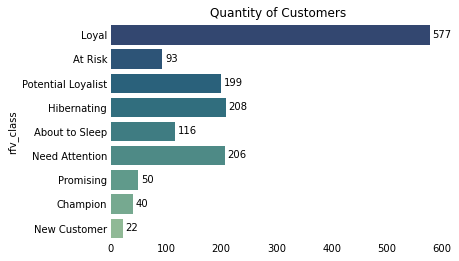

In [27]:
cluster_count_plot(customer_abt, cluster_col='rfv_class')

### 3.1 Sales and Profit

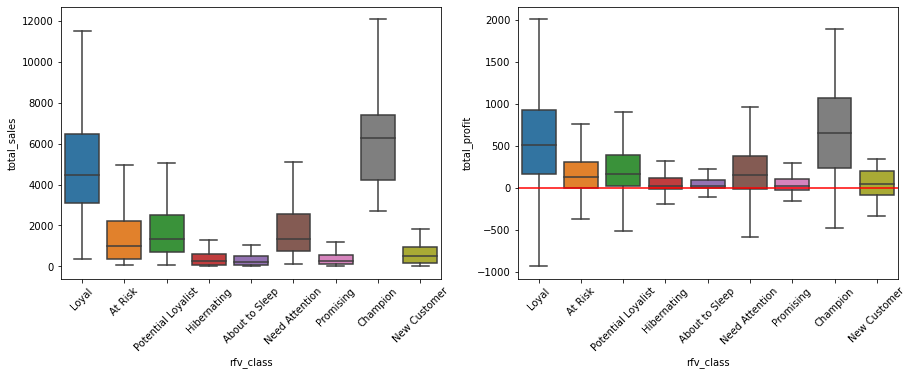

In [28]:
compare_clusters( cluster='rfv_class', y=['total_sales', 'total_profit'], data=customer_abt, xticks_rotation=45)
plt.axhline(0, color='r');

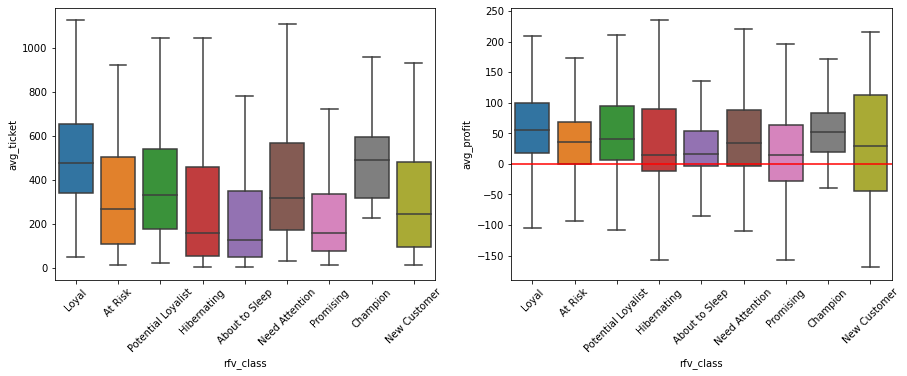

In [29]:
compare_clusters( cluster='rfv_class', y=['avg_ticket', 'avg_profit'], data=customer_abt, xticks_rotation=45)
plt.axhline(0, color='r');

In [30]:
cluster_stats(customer_abt, cluster='rfv_class', column='total_sales').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
rfv_class,,,,,,,,,
Champion,6521.570218,2718.676732,2712.59904,4243.860925,6255.64090,7385.30970,8048.561804,11108.632380,12512.8473
Loyal,5064.024688,2840.775503,337.56700,3084.208000,4481.64040,6491.49844,6984.838856,8494.556600,23295.2184
Need Attention,1928.319484,1801.702105,95.01000,744.807000,1338.85418,2544.57450,2906.445000,4078.404000,11885.0992
Potential Loyalist,1896.414530,1750.966301,80.40000,691.995000,1328.44500,2490.68905,2823.172800,4349.584432,12252.1050
At Risk,1660.390930,1806.110405,43.06800,377.970000,970.14600,2214.50300,2661.096000,4452.118800,7841.2935
New Customer,863.445682,1226.998140,13.44000,161.706000,493.54500,946.55250,961.888800,1761.604200,5460.0900
Hibernating,480.678538,622.225561,2.58000,71.488500,273.33000,590.33550,726.800400,1193.964000,4042.5000
About to Sleep,416.419267,545.761192,2.05200,74.062500,226.93500,506.57550,697.410000,967.395000,3470.1000
Promising,414.851580,397.458004,14.20800,113.866500,274.06950,561.63300,701.256000,1111.783200,1564.5600


### 3.2 Orders and Quantity of Products

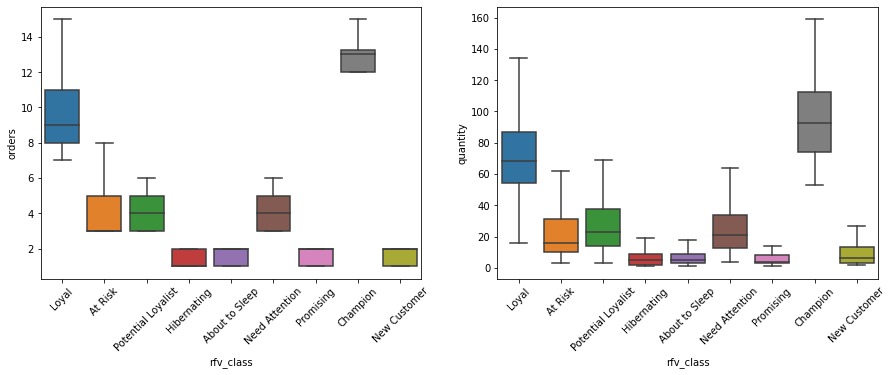

In [31]:
compare_clusters( cluster='rfv_class', y=['orders', 'quantity'], data=customer_abt, xticks_rotation=45)

In [32]:
cluster_stats(customer_abt, cluster='rfv_class', column='orders').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
rfv_class,,,,,,,,,
Champion,12.875000,1.042372,12.0,12.0,13.0,13.25,14.0,14.0,16.0
Loyal,9.674177,2.318684,7.0,8.0,9.0,11.00,11.0,13.0,21.0
Potential Loyalist,4.417085,1.146761,3.0,3.0,4.0,5.00,6.0,6.0,6.0
Need Attention,4.325243,1.183646,3.0,3.0,4.0,5.00,6.0,6.0,6.0
At Risk,4.247312,1.761027,3.0,3.0,3.0,5.00,5.0,7.0,10.0
New Customer,1.681818,0.476731,1.0,1.0,2.0,2.00,2.0,2.0,2.0
Promising,1.640000,0.484873,1.0,1.0,2.0,2.00,2.0,2.0,2.0
About to Sleep,1.620690,0.487320,1.0,1.0,2.0,2.00,2.0,2.0,2.0
Hibernating,1.432692,0.496644,1.0,1.0,1.0,2.00,2.0,2.0,2.0


### 3.3 Recency and Frequency

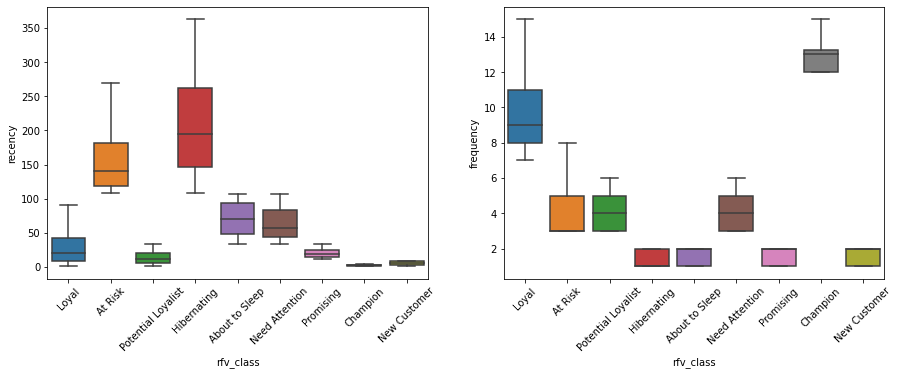

In [33]:
compare_clusters( cluster='rfv_class', y=['recency', 'frequency'], data=customer_abt, xticks_rotation=45)

In [34]:
cluster_stats(customer_abt, cluster='rfv_class', column='recency').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
rfv_class,,,,,,,,,
Hibernating,209.394231,72.071210,108.0,146.00,194.5,262.75,282.6,315.6,363.0
At Risk,153.225806,40.553542,108.0,118.00,141.0,182.00,189.8,207.8,269.0
About to Sleep,70.482759,23.670008,34.0,49.00,70.5,93.00,94.0,101.0,107.0
Need Attention,64.179612,23.031088,34.0,44.00,57.5,83.75,89.0,99.5,107.0
Loyal,28.753899,23.458113,1.0,9.00,21.0,42.00,46.0,64.0,105.0
Promising,19.700000,6.068487,12.0,14.00,19.0,24.75,26.2,29.0,33.0
Potential Loyalist,13.422111,8.723746,1.0,6.00,12.0,21.00,23.0,26.0,33.0
New Customer,5.363636,2.903946,1.0,2.25,6.0,8.00,8.0,8.9,9.0
Champion,2.650000,1.251666,1.0,2.00,3.0,3.00,3.2,5.0,5.0


### 3.4 Discount and Shipping Cost

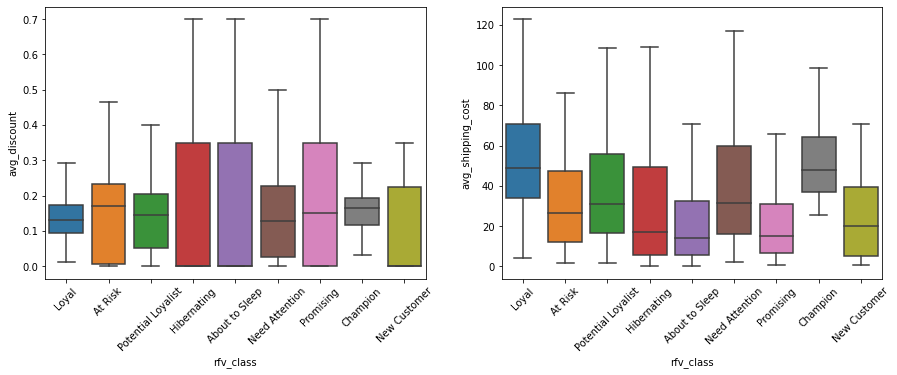

In [35]:
compare_clusters( cluster='rfv_class', y=['avg_discount', 'avg_shipping_cost'], data=customer_abt, xticks_rotation=45)

In [36]:
cluster_stats(customer_abt, cluster='rfv_class', column='avg_discount').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
rfv_class,,,,,,,,,
Promising,0.216000,0.244832,0.000000,0.000000,0.150000,0.350000,0.360000,0.600000,0.700000
Hibernating,0.178005,0.255661,0.000000,0.000000,0.000000,0.350000,0.350000,0.600000,0.700000
About to Sleep,0.171983,0.242028,0.000000,0.000000,0.000000,0.350000,0.350000,0.600000,0.700000
Champion,0.159422,0.052835,0.030800,0.117002,0.164131,0.193571,0.200048,0.221212,0.292583
At Risk,0.156194,0.125373,0.000000,0.006667,0.170000,0.233333,0.237333,0.296667,0.466667
Potential Loyalist,0.144864,0.115139,0.000000,0.051389,0.146667,0.203500,0.233333,0.286267,0.525000
Need Attention,0.140116,0.121841,0.000000,0.025417,0.127778,0.227542,0.233333,0.300000,0.633333
Loyal,0.135796,0.060078,0.012583,0.092857,0.131026,0.172714,0.185638,0.215111,0.371429
New Customer,0.118182,0.210750,0.000000,0.000000,0.000000,0.225000,0.340000,0.350000,0.650000


#### 3.5 Location
Due to lack of metadata We can't answer location questions accuratly.

One's customers made a purchase in that country (is he there?) or send the purchased item to that country?

In [37]:
cols = ['customer_id', 'segment', 'city', 'state', 'country', 'market', 'region', 'product_id']
aux = data[cols]
aux = customer_abt.merge(aux, on='customer_id', how='inner')
aux.head(2)

,customer_id,orders,total_sales,quantity,total_profit,avg_discount,is_profitable_sale,total_shipping_cost,avg_ticket,distinct_products,avg_profit,avg_shipping_cost,recency,frequency,value,avg_value,recency_rank,frequency_rank,value_rank,avg_value_rank,rfv_class,segment,city,state,country,market,region,product_id
0,AA-10315,7,3889.2065,53,534.2215,0.142857,0.642857,485.51,555.600929,17,76.317357,69.358571,9,7,3889.2065,228.776853,0.816347,0.621443,0.705493,0.614163,Loyal,Consumer,Marikina,National Capital,Philippines,APAC,Southeast Asia,OFF-SU-10001308
1,AA-10315,7,3889.2065,53,534.2215,0.142857,0.642857,485.51,555.600929,17,76.317357,69.358571,9,7,3889.2065,228.776853,0.816347,0.621443,0.705493,0.614163,Loyal,Consumer,Marikina,National Capital,Philippines,APAC,Southeast Asia,OFF-LA-10000425


In [38]:
aux.groupby('customer_id')['country'].unique().head()#.max()#.hist()

customer_id
AA-10315    [Philippines, United States, Mexico, Germany, ...
AA-10375    [New Zealand, United States, Mexico, Haiti, Af...
AA-10480    [France, United States, United Kingdom, Indone...
AA-10645    [United States, United Kingdom, Indonesia, Dom...
AA-315             [Turkey, Ukraine, Belarus, Russia, Guinea]
Name: country, dtype: object

In [39]:
aux.groupby('customer_id')[cols].nunique().max()

customer_id     1
segment         1
city           40
state          35
country        25
market          4
region         10
product_id     97
dtype: int64

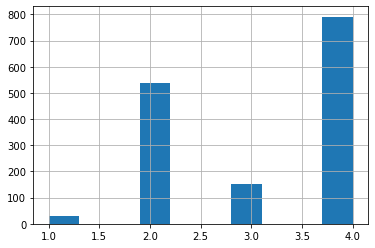

In [40]:
aux.groupby('customer_id')['market'].nunique().hist();

### 4 Objective Answers

- **Who are our best customers?**

        Champions.
            They buy a lot and are always buying.


- **Where are they?**

Due to [lack of metadata](#3.5-Location) We can't answer location questions accuratly.


- **Who has the potential to become valuable customers?**

        Potential Loyalists, Promisings, and Need Attention.
            Similar average of orders and quantity of products,
            different recency.
            They're all good customers, but as time passes by They 
            change their RFV status.
            Potential Loyalists might Need Attention (stop buying)
            Promisings might become one or another.


- **Which of our customers are most likely to respond to engagement campaigns?**
        
        Need Attention.
            They're basically promising customers who have not been
            buying recently. So a Promotional Campaign can bring them
            back to spending.
        
        New Customer.
            First purchases. Potential to buy more, mainly if there's
            a engagement campaign.

_The more recent the purchase, the more responsive the customer is to promotions_
            

- **Which of our customers can be retained?**

        At Risk
            They used to be Loyal. Client has used the products and 
            for some reason stopped buying. But there's still chance 
            to get them back.


## 5 Strategies

Basic Overview:

    High Value: Improve Retention

    Mid Value: Improve Retention + Increase Frequency

    Low Value: Increase Frequency
    
On the other Hand:

![img](../images/rfv_strategies1.png)

![img](../images/rfv_strategies2.png)


_The more recent the purchase, the more responsive the customer is to promotions_

_The more frequently the customer buys, the more engaged and satisfied they are_

_Monetary value differentiates heavy spenders from low-value purchasers_

In [41]:
if len(years) > 1:
    file_name = f'e_mart_customer_abt_{years[0]}_to_{years[-1]}.parquet'
else:
    file_name = f'e_mart_customer_abt_{years[-1]}.parquet'
customer_abt.to_parquet(join_paths([directory.DATA_DIR, 'processed', file_name]))

In [42]:
file_name

'e_mart_customer_abt_2014.parquet'